# Ex 5

Contributors: Matrim Cirullo-Nesbitt, Abhishek Vilekar, Andrew Gabaldon.

We have tools to study 1D unforced oscillators. Now we pick our own, that has a local minimum (not driven).

### 5a.)

Present the potential and describe its origin, why it is interesting, where it comes from, etc. Educate us about it.

We take the Bloch oscillation from solid-state physics (a field in which I have great interest). From [this](http://staff.ustc.edu.cn/~zqj/posts/1D-BlochOscillation/) website, the Bloch oscillation is the oscillation in real and momentum-space (called k-space), when a constant force is acting on a particle. The model below is a simplistic, 1-D representation of the effect.
$$ V(x) = 2v_0\cos(\frac{2\pi}{a}x)$$

### 5b.)

Sketch or plot the potential as a function of its argument (and chosen variables) and find the equilibrium position of the potential, i.e. the position where the potential is at a minimum.

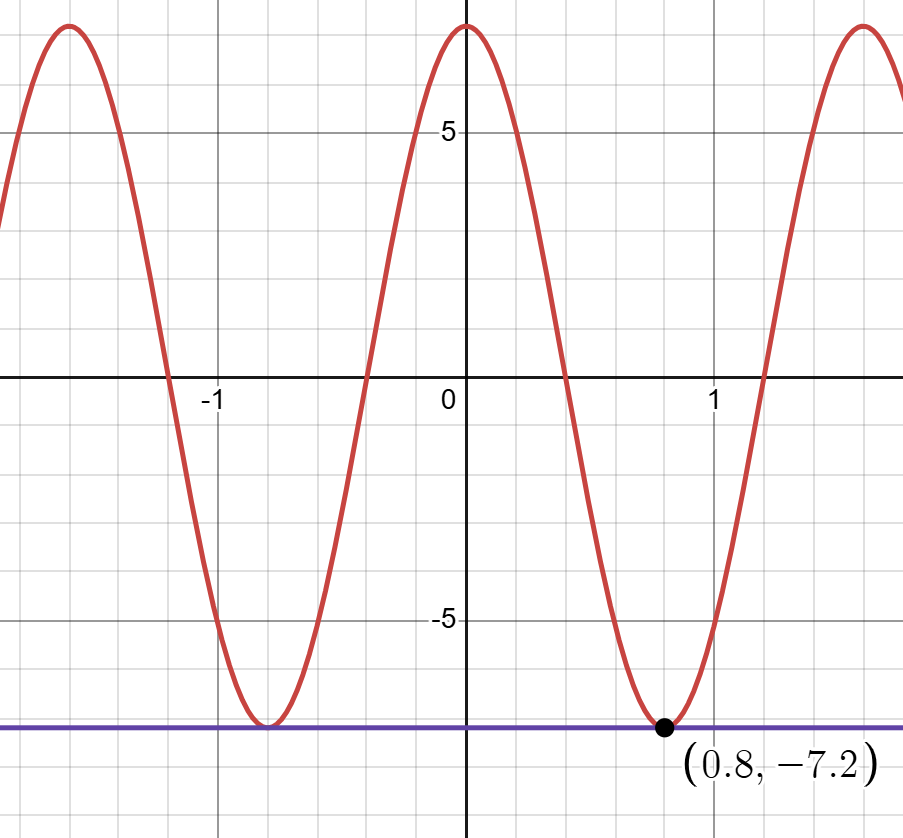


The red line is the potential curve, the purple line represents the line $y=-2v_0$, which denotes the line in which all minima of the potential fall on. The black point is exactly, $(\frac{a}{2},-V(a))$, which is the first minimum point of the function.

### 5c.)

Rewrite the potential in terms of the displacement from equilibrium. Expand the potential to second order to find the effective spring constant, $k$, for the potential near the minimum. What is the frequency of small oscillations about the minimum?

We arbitrarily define the potential at the minimum to be zero. Thus $V(\frac{a}{2}) = 0$
We let $r = x-\frac{a}{2}$. Then we perform a taylor expansion of the potential energy around $\frac{a}{2}$,
$$V(x) \approx V(\frac{a}{2}) + \frac{dV}{dx}|_{\frac{a}{2}}(x-\frac{a}{2}) + \frac{1}{2}\frac{d^2V}{dx^2}|_{\frac{a}{2}}(x-\frac{a}{2})^2$$



Which we evaluate to be 
$$V(x) \approx 0 + 0 + \frac{1}{2}\frac{d^2V}{dx^2}|_{\frac{a}{2}}(x-\frac{a}{2})^2.$$
We evaluate the second derivative of $V(x)$ at $\frac{a}{2}$,
$$\frac{d^2V(x)}{dx^2} = -\frac{8v_0\pi^2}{a^2}\cos(\frac{2\pi}{a}x)$$
$$\frac{d^2V}{dx^2}|_{\frac{a}{2}} = -\frac{8v_0\pi^2}{a^2}\cos(\pi) = \frac{8v_0\pi^2}{a^2}.$$
Thus, 
$$V(x) \approx \frac{4v_0\pi^2}{a^2}r^2.$$
In this case our spring constant, $k = \frac{4v_0\pi^2}{a^2}$, and since $\frac{1}{2\pi}\sqrt{\frac{k}{m}} = \frac{1}{2\pi}\omega = f$,

$$f = \frac{1}{a}\sqrt{\frac{v_0}{m}}.$$


### 5d.)

Construct the equations of motion for the potential and solve them numerically. Choose initial conditions and parameters that give oscillatory motion. Note it doesn’t have to be SHO (In fact, it probably won’t be). Plot the position as a function of time. Make sure we can see the oscillations.

Recall that the equations of motion of a system are given by
$$\frac{d^2\vec{r}}{dt^2} = -\nabla V(\vec{r}),$$
and in one-dimension, this is 
$$\ddot{x} = -\frac{dV(x)}{dx},$$
so the equations of motion are
$$\ddot{x} = -\frac{4v_0\pi}{a}\sin(\frac{2\pi}{a}x),$$
Which is difficult to solve directly.
We make this into a slightly easier form by reducing the order of the equation,
$$\dot{v} = -\frac{4v_0\pi}{a}\sin(\frac{2\pi}{a}x)$$
$$\dot{x} = v$$
We create and copy some code from the previous assignment to do the integration here.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import UsefulFuncs as uf
%matplotlib inline

plt.style.use('seaborn-v0_8-colorblind')

def BloschAcc(x,v,V_0,a):
    return -(4 * V_0 * np.pi)/(a) * np.sin((2*np.pi * x)/a)
#define our acceleration

t_0 = 0
t_f = 5
dt = 1/100
x_0 = 4*np.pi
v_0 = 0
V_0 = 2
a = 3
#define initial conditions

add_conds = (V_0,a)

t,x,v = uf.RK2O_gen(x_0,v_0,t_0,t_f,dt,acc_func=BloschAcc,fargs=add_conds) #integrate EoM
blosch_df = pd.DataFrame({'t': t, 'x': x, 'v': v}) #set to dataframe

fig, ax = plt.subplots(1,1,figsize=(8,8))
ax.set_title("Blosch Oscillation Time-Position Plot")
ax.plot(blosch_df['t'],blosch_df['x'])
ax.set_xlabel("Time (s)")
ax.set_ylabel("Position (m)")
ax.grid()
plt.show()

### 5e.)

Plot the phase diagram of the trajectory (you don’t have to produce a phase diagram, but just plot the trajectory in phase space). What does the phase diagram tell you about the motion?

We use our previous code to produce a phase diagram and plot the trajectory on the diagram.

In [ ]:
xlim = (11.4,12.6)
vlim = (-5,5)
gridsize = 20

x,v,dx,dv = uf.Gen_Phase_Space(xlim,vlim,gridsize,BloschAcc,add_conds)

fig,ax = plt.subplots(1,1,figsize=(8,8))

ax.quiver(x,v,dx,dv,color="C0")
ax.plot(blosch_df['x'],blosch_df['v'])
ax.set_xlabel("Position (m)")
ax.set_ylabel("Velocity (m/s)")
ax.set_title(r"Blosch Oscillation Phase Space, $x$ vs $\dot{x}$")
plt.show()

The phase diagram implies that the motion here is oscillatory, and conservative.

### 5f.)

Find the period of your motion. Here you might have to make some definitions of what periodicity means for your potential.

The period of our motion is about 1 full oscillation per 1.625 seconds.